In [1]:
import numpy as np
import time

def simNoise(sqrtSn=1, Tsft=7200, size=(256,128), ndet=2, norm=True, seed=None):
    """
    Generates Gaussian noise in the frequency domain with given parameters.

    Parameters:
        Tsft (float): Total time duration for Fourier transform.
        size (tuple): Shape of each dataset in the form (num_bins, num_segments).
        ndet (int): Number of detector.

    Returns:
        np.ndarray: Generated noise data with shape (num_segments, num_bins, 2*ndet).
    """
    
    if seed is not None:
        np.random.seed(seed)
    
    sigma = 0.5 * sqrtSn * np.sqrt(Tsft)  # Variance for real and imaginary parts 

    dataset = np.empty(size + (2*ndet,))
    for i in range(ndet):  # Two time series
        dataset[...,2*i] = np.random.normal(0, sigma, size)
        dataset[...,2*i+1] = np.random.normal(0, sigma, size)
        
    if norm:
        return normalize(dataset)
    else:
        return dataset

def normalize(data, channel=False):
    """
    Normalizes each image using the global min and max across all channels.
    Supports single images (m, n, c) or batches (num, m, n, c).
    
    Parameters:
        data (numpy.ndarray): Input image(s) with shape (m, n, c) or (num, m, n, c).
    
    Returns:
        numpy.ndarray: Normalized image(s) with the same shape, scaled to [-1, 1].
    """
    # Ensure input is a 3D or 4D array
    if data.ndim not in (3, 4):
        raise ValueError("Input must be a 3D array (m, n, c) or 4D array (num, m, n, c)")
    
    # Compute min and max across all channels
    if data.ndim == 3:
        if channel:
            # Single image: min/max over all pixels and channels
            xmin = np.min(data, axis=(0, 1), keepdims=True)
            xmax = np.max(data, axis=(0, 1), keepdims=True)
        else:
            xmin = np.min(data, keepdims=True)
            xmax = np.max(data, keepdims=True)
    else:
        if channel:
            # Single image: min/max over all pixels and channels
            xmin = np.min(data, axis=(1, 2), keepdims=True)
            xmax = np.max(data, axis=(1, 2), keepdims=True)
        else:
            xmin = np.min(data, axis=(1, 2, 3), keepdims=True)
            xmax = np.max(data, axis=(1, 2, 3), keepdims=True)
     
    # Avoid division by zero by setting denominator to 1 where max equals min
    denom = xmax - xmin
    #denom = np.where(denom == 0, 1, denom)
    
    # Normalize to [0, 1] per image, then scale to [-1, 1]
    normalized_data = (data - xmin) / denom
    normalized_data = normalized_data * 2 - 1
    
    return normalized_data
# Test 1: Speed Test
print("=== Speed Test ===")


=== Speed Test ===


In [10]:

# 1.1: For-loop to generate 1000 noise datasets with size (200, 100)
start_time = time.time()
noise_forloop = np.empty((1000, 200, 100, 4))
for i in range(1000):
    noise_forloop[i] = simNoise(sqrtSn=1, Tsft=7200, size=(200, 100), ndet=2, norm=True, seed=i)
time_forloop = time.time() - start_time
print(f"1.1 For-loop (1000 x (200, 100)): {time_forloop:.2f} seconds")

# 1.2: Direct generation with size (1000, 200, 100)
start_time = time.time()
noise_direct = simNoise(sqrtSn=1, Tsft=7200, size=(1000, 200, 100), ndet=2, norm=True, seed=None)
time_direct = time.time() - start_time
print(f"1.2 Direct ((1000, 200, 100)): {time_direct:.2f} seconds")


1.1 For-loop (1000 x (200, 100)): 3.30 seconds
1.2 Direct ((1000, 200, 100)): 4.83 seconds


In [11]:
# Test 2: Identical Noise Test
print("\n=== Identical Noise Test ===")

# 2.1: For-loop with different random seeds
noise_forloop_seeds = np.empty((1000, 200, 100, 4))
for i in range(1000):
    noise_forloop_seeds[i] = simNoise(sqrtSn=1, Tsft=7200, size=(200, 100), ndet=2, norm=True, seed=i)
# Check if all 1000 datasets are different
are_different = [not np.array_equal(noise_forloop_seeds[0], noise_forloop_seeds[i]) for i in range(1, 1000)]
print(f"2.1 For-loop with different seeds: All 1000 noises different? {all(are_different)}")

# 2.2: Direct generation, check if slices are identical
# Compare first few slices of noise_direct
are_identical = [np.array_equal(noise_direct[0], noise_direct[i]) for i in range(1, min(5, 1000))]
print(f"2.2 Direct generation: Are first few slices identical? {any(are_identical)}")
# Check statistical similarity (mean and std) across slices to confirm different noise
means = np.mean(noise_direct, axis=(1, 2, 3))
stds = np.std(noise_direct, axis=(1, 2, 3))
print(f"2.2 Direct generation: Mean range: {means.min():.4f} to {means.max():.4f}, Std range: {stds.min():.4f} to {stds.max():.4f}")


=== Identical Noise Test ===
2.1 For-loop with different seeds: All 1000 noises different? True
2.2 Direct generation: Are first few slices identical? False
2.2 Direct generation: Mean range: -0.1603 to 0.1690, Std range: 0.1978 to 0.2582



=== Mean and Std Calculation ===
For-loop: Mean range: -0.1700 to 0.1452, Std range: 0.1973 to 0.2564
Direct: Mean range: -0.1603 to 0.1690, Std range: 0.1978 to 0.2582


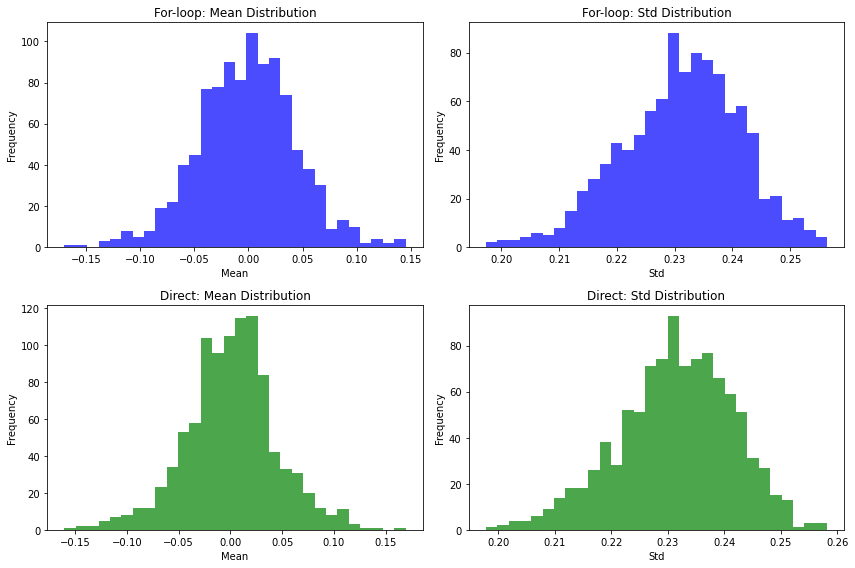

In [12]:
import matplotlib.pyplot as plt
# Test 3: Mean and Std Calculation
print("\n=== Mean and Std Calculation ===")

# Calculate mean and std for each of the 1000 datasets
means_forloop = np.mean(noise_forloop, axis=(1, 2, 3))
stds_forloop = np.std(noise_forloop, axis=(1, 2, 3))
means_direct = np.mean(noise_direct, axis=(1, 2, 3))
stds_direct = np.std(noise_direct, axis=(1, 2, 3))

print(f"For-loop: Mean range: {means_forloop.min():.4f} to {means_forloop.max():.4f}, Std range: {stds_forloop.min():.4f} to {stds_forloop.max():.4f}")
print(f"Direct: Mean range: {means_direct.min():.4f} to {means_direct.max():.4f}, Std range: {stds_direct.min():.4f} to {stds_direct.max():.4f}")

# Plotting
plt.figure(figsize=(12, 8))

# Histogram of Means (For-loop)
plt.subplot(2, 2, 1)
plt.hist(means_forloop, bins=30, color='blue', alpha=0.7)
plt.title('For-loop: Mean Distribution')
plt.xlabel('Mean')
plt.ylabel('Frequency')

# Histogram of Stds (For-loop)
plt.subplot(2, 2, 2)
plt.hist(stds_forloop, bins=30, color='blue', alpha=0.7)
plt.title('For-loop: Std Distribution')
plt.xlabel('Std')
plt.ylabel('Frequency')

# Histogram of Means (Direct)
plt.subplot(2, 2, 3)
plt.hist(means_direct, bins=30, color='green', alpha=0.7)
plt.title('Direct: Mean Distribution')
plt.xlabel('Mean')
plt.ylabel('Frequency')

# Histogram of Stds (Direct)
plt.subplot(2, 2, 4)
plt.hist(stds_direct, bins=30, color='green', alpha=0.7)
plt.title('Direct: Std Distribution')
plt.xlabel('Std')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('noise_stats_plots.png')
plt.show()